In [ ]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))
print(sys.path)

from BPMN.optimization import *
torch.set_default_dtype(torch.float64)
from libSOGAtruncate import truncate
import time

import torch
from torch.distributions import Normal, Categorical
import math

import BPMN.data_generating_process as dgp
import BPMN.helper_plots as hp
import matplotlib.pyplot as plt
import numpy as np

compiledFile=compile2SOGA('programs/parallel.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

params = {
'mu0': 1., # START
'mu1': 20., # A_SUBMITTED
'mu2': 20., # A_PARTLYSUBMITTED
'mu3': 90., # W_Assess_fraud
'mu4': 120., # W_Fix_incomplete_submission
'mu5': 6., # A_PREACCEPTED
'mu6': 90., # W_Complete_preaccepted_appl
'mu7': 6., # A_ACCEPTED
'mu8': 6., # A_FINALIZED
'mu9': 6., # O_SELECTED
'mu10': 6., # O_CREATED
'mu11': 6., # O_SENT
'mu12': 60., # W_Call_after_offer
'mu13': 6., # O_SENT_BACK
'mu14': 90., # W_Call_missing_information
'mu15': 120., # W_Assess_application
'mu16': 6., # O_CANCELLED
'mu17': 6., # A_CANCELLED
'mu18': 6., # A_DECLINED
'mu19': 6., # O_DECLINED
'mu20': 6., # O_ACCEPTED
'mu21': 6., # A_APPROVED
'mu22': 6., # A_REGISTERED
'mu23': 6., # A_ACTIVATED
'mu24': 1., # END

'p0': 0.9,
'p1': 0.3,
'p2': 0.3,
'p3': 0.8,
'p4': 0.8,
'p5': 0.7,
'p6': 0.2,
'p7': 0.8,
'p8': 0.2,
'p9': 0.4,
'p10': 0.2,
'p11': 0.7,
'p12': 0.8,
'p13': 0.2,
'p14': 0.4,
'p15': 0.8
}

for key in params:
    params[key] = params[key] ** 0.5

params_dict = initialize_params(params)
output_dist = start_SOGA(cfg, params_dict)
print(output_dist.gm.pi.shape)



['/home/rdoz/miniconda3/envs/myenv/lib/python313.zip', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13/lib-dynload', '', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages', '/home/rdoz/PhD/DeGAS/src']


/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Parallel experiment

In [ ]:
compiledFile=compile2SOGA('programs/parallel.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

params = {
'mu0': 1., # START
'mu1': 20., # A_SUBMITTED
'mu2': 20., # A_PARTLYSUBMITTED
'mu3': 90., # W_Assess_fraud
'mu4': 120., # W_Fix_incomplete_submission
'mu5': 6., # A_PREACCEPTED
'mu6': 90., # W_Complete_preaccepted_appl
'mu7': 6., # A_ACCEPTED
'mu8': 6., # A_FINALIZED
'mu9': 6., # O_SELECTED
'mu10': 6., # O_CREATED
'mu11': 6., # O_SENT
'mu12': 60., # W_Call_after_offer
'mu13': 6., # O_SENT_BACK
'mu14': 90., # W_Call_missing_information
'mu15': 120., # W_Assess_application
'mu16': 6., # O_CANCELLED
'mu17': 6., # A_CANCELLED
'mu18': 6., # A_DECLINED
'mu19': 6., # O_DECLINED
'mu20': 6., # O_ACCEPTED
'mu21': 6., # A_APPROVED
'mu22': 6., # A_REGISTERED
'mu23': 6., # A_ACTIVATED
'mu24': 1., # END

'p0': 0.9,
'p1': 0.3,
'p2': 0.3,
'p3': 0.8,
'p4': 0.8,
'p5': 0.7,
'p6': 0.2,
'p7': 0.8,
'p8': 0.2,
'p9': 0.4,
'p10': 0.2,
'p11': 0.7,
'p12': 0.8,
'p13': 0.2,
'p14': 0.4,
'p15': 0.8
}

for key in params:
    params[key] = params[key] ** 0.5

params_dict = initialize_params(params)
output_dist = start_SOGA(cfg, params_dict)
print(output_dist.gm.pi.shape)


In [3]:
# computes SOGA output
output_dist = start_SOGA(cfg, params_dict)

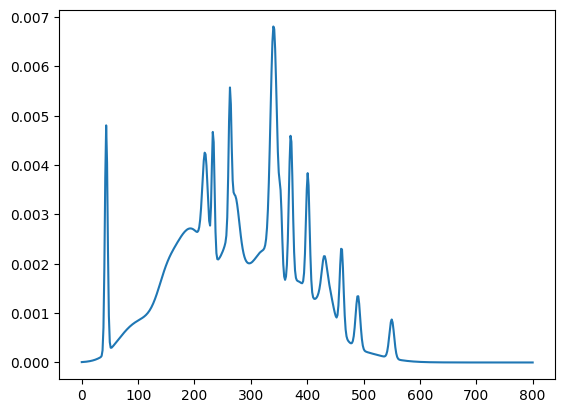

In [4]:
xs, pdf = hp.evaluate_marginal(output_dist, 't', 0, 800, 500)
plt.plot(xs.numpy(), pdf.numpy())

In [10]:
output_dist.gm.pi.shape

torch.Size([40, 1])

In [6]:
loss = lambda output_dist: -output_dist.gm.marg_pdf(torch.tensor([10000.]), output_dist.var_list.index('t'))
print(loss(output_dist))

tensor([[-0.]], grad_fn=<NegBackward0>)


## Compare with sampling

In [7]:
def sample_positive_normal(mean, variance=1.0):
    while True:
        value = torch.distributions.Normal(mean, variance).sample().item()
        if value > 0.0:
            return value

endacts_samples shape: torch.Size([5000, 25])
total_time_samples shape: torch.Size([5000])
mean total time: 255.14943553079613
mean endacts: tensor([  0.9993,  20.9915,  40.9862,  34.7211,  50.7913,  78.7104, 143.4137,
        118.5137,  96.6342,  96.6423,  99.9493, 103.2555,  56.7761,  23.8148,
        117.0338, 104.0813,  25.8235,  38.9735,  80.2703,  68.2597, 117.5729,
        120.4594, 123.3473, 126.2444, 255.1494])


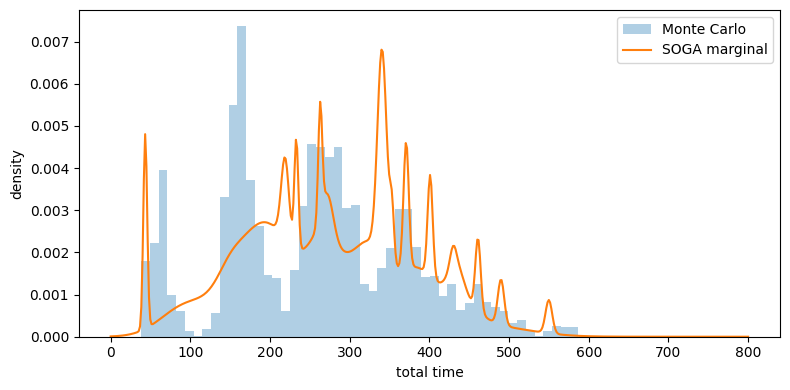

In [8]:
nsamples = 5000





def simulate_parallel_once(params):
    tacts = torch.zeros(25, dtype=torch.float64)
    startacts = torch.zeros(25, dtype=torch.float64)
    endacts = torch.zeros(25, dtype=torch.float64)
    t = 0.0

    mus = [float(params[f"mu{i}"]) ** 2 for i in range(25)]
    probs = [float(params[f"p{i}"]) ** 2 for i in range(16)]

    for i, mean in enumerate(mus):
        if i == 0 or i == 24:
            tacts[i] = sample_positive_normal(mean, variance = 0.1)
        else:
            tacts[i] = sample_positive_normal(mean)

    def u01():
        return torch.rand(()).item()

    # START -> A_SUBMITTED -> A_PARTLYSUBMITTED
    startacts[0] = t
    endacts[0] = startacts[0] + tacts[0]
    t = endacts[0].item()

    startacts[1] = t
    endacts[1] = startacts[1] + tacts[1]
    t = endacts[1].item()

    startacts[2] = t
    endacts[2] = startacts[2] + tacts[2]
    t = endacts[2].item()

    if u01() < probs[0]:
        if u01() < probs[1]:
            startacts[3] = t
            endacts[3] = startacts[3] + tacts[3]
            t = endacts[3].item()

        if u01() < probs[2]:
            startacts[4] = t
            endacts[4] = startacts[4] + tacts[4]
            t = endacts[4].item()

        if u01() < probs[3]:
            startacts[5] = t
            endacts[5] = startacts[5] + tacts[5]
            t = endacts[5].item()

            startacts[6] = t
            endacts[6] = startacts[6] + tacts[6]
            t = endacts[6].item()

            if u01() < probs[4]:
                startacts[7] = t
                endacts[7] = startacts[7] + tacts[7]
                t = endacts[7].item()

    if u01() < probs[5]:
        branch0 = t
        branch1 = t

        if u01() < probs[7]:
            branch00 = branch0
            branch01 = branch0

            startacts[8] = branch00
            endacts[8] = startacts[8] + tacts[8]
            branch00 = endacts[8].item()

            startacts[9] = branch01
            endacts[9] = startacts[9] + tacts[9]
            branch01 = endacts[9].item()

            startacts[10] = branch01
            endacts[10] = startacts[10] + tacts[10]
            branch01 = endacts[10].item()

            startacts[11] = branch01
            endacts[11] = startacts[11] + tacts[11]
            branch01 = endacts[11].item()

            if u01() < probs[9]:
                startacts[12] = branch01
                endacts[12] = startacts[12] + tacts[12]
                branch01 = endacts[12].item()

            if u01() < probs[10]:
                startacts[13] = branch01
                endacts[13] = startacts[13] + tacts[13]
                branch01 = endacts[13].item()

            if u01() < probs[11]:
                branch10 = branch01
                branch11 = branch01

                if u01() < probs[12]:
                    startacts[15] = branch10
                    endacts[15] = startacts[15] + tacts[15]
                    branch10 = endacts[15].item()

                startacts[14] = branch11
                endacts[14] = startacts[14] + tacts[14]
                branch11 = endacts[14].item()

                branch01 = max(branch10, branch11)

            branch0 = max(branch00, branch01)

        if u01() < probs[8]:
            startacts[17] = branch0
            endacts[17] = startacts[17] + tacts[17]
            branch0 = endacts[17].item()

        if u01() < probs[6]:
            startacts[16] = branch1
            endacts[16] = startacts[16] + tacts[16]
            branch1 = endacts[16].item()

        t = max(branch0, branch1)

    if u01() < probs[13]:
        pass
    else:
        if u01() < probs[14]:
            startacts[18] = t
            endacts[18] = startacts[18] + tacts[18]
            t = endacts[18].item()

            if u01() < probs[15]:
                startacts[19] = t
                endacts[19] = startacts[19] + tacts[19]
                t = endacts[19].item()
        else:
            startacts[20] = t
            endacts[20] = startacts[20] + tacts[20]
            t = endacts[20].item()

            startacts[21] = t
            endacts[21] = startacts[21] + tacts[21]
            t = endacts[21].item()

            startacts[22] = t
            endacts[22] = startacts[22] + tacts[22]
            t = endacts[22].item()

            startacts[23] = t
            endacts[23] = startacts[23] + tacts[23]
            t = endacts[23].item()

    startacts[24] = t
    endacts[24] = startacts[24] + tacts[24]
    t = endacts[24].item()

    return endacts, t


endacts_samples = torch.zeros((nsamples, 25), dtype=torch.float64)
total_time_samples = torch.zeros(nsamples, dtype=torch.float64)

for i in range(nsamples):
    endacts_i, total_time_i = simulate_parallel_once(params)
    endacts_samples[i] = endacts_i
    total_time_samples[i] = total_time_i

print("endacts_samples shape:", endacts_samples.shape)
print("total_time_samples shape:", total_time_samples.shape)
print("mean total time:", total_time_samples.mean().item())
print("mean endacts:", endacts_samples.mean(dim=0))

xs, pdf = hp.evaluate_marginal(output_dist, 't', 0, 800, 500)
plt.figure(figsize=(8, 4))
plt.hist(total_time_samples.numpy(), bins=50, density=True, alpha=0.35, label='Monte Carlo')
plt.plot(xs.numpy(), pdf.numpy(), label='SOGA marginal')
plt.xlabel('total time')
plt.ylabel('density')
plt.legend()
plt.tight_layout()
plt.show()

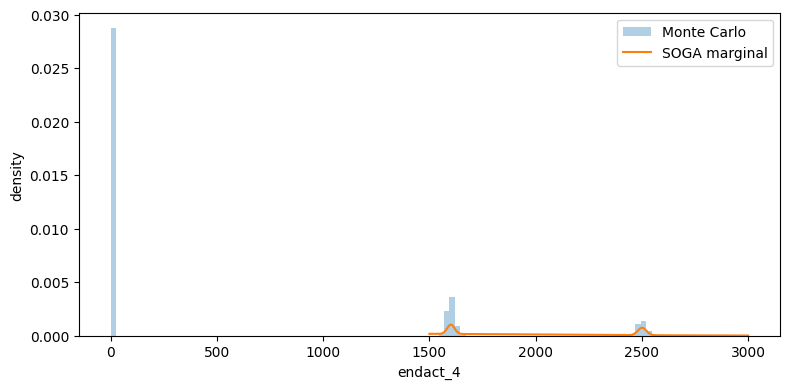

In [43]:
#compare some of the endacts of the simulation with the marginals of SOGA
j = 4
xs, pdf = hp.evaluate_marginal(output_dist, f'endacts[{j}]', 1500, 3000, 500)
plt.figure(figsize=(8, 4))
plt.hist(endacts_samples[:, j].numpy(), bins=100, density=True, alpha=0.35, label='Monte Carlo')
plt.plot(xs.numpy(), pdf.numpy(), label='SOGA marginal')
plt.xlabel(f'endact_{j}')
plt.ylabel('density')
#plt.xlim(1200, 1350)
plt.legend()
plt.tight_layout()
plt.show()


## Optimization

In [ ]:
start_time = time.time()
# gradient based optimization
loss_list = optimize(cfg, params_dict, loss, n_steps=200, lr=0.0001)

end_time = time.time()
execution_time = end_time - start_time
print(f"Optimization execution time: {execution_time} seconds")

# Purchasing experiment

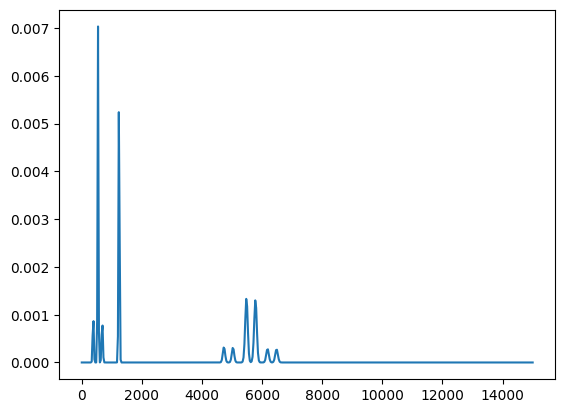

In [7]:
params = {
'mu0': 40.,
'mu1': 500.,
'mu2': 700.,
'mu3': 300.,
'mu4': 40.,
'mu5': 300.,
'mu6': 500.,
'mu7': 500.,
'mu8': 350.,
'mu9': 200.,
'mu10': 700.,
'mu11': 350.,
'mu12': 200.,
'mu13': 800.,
'mu14': 350.,
'mu15': 200.,
'mu16': 200.,
'mu17': 350.,
'mu18': 700.,
'mu19': 200.,
'mu20': 200.,

'p0': 0.5, # after Create Purchase Requisition -> Analyze Purchase Requisition
'p1': 0.5, # after Analyze Purchase Requisition -> Amend Purchase Requisition
'p2': 0.5, # after Analyze Request for Quotation -> Amend Request for Quotation
'p3': 0.8, # after RFQ block -> Send Request for Quotation to Supplier
'p4': 0.8, # after Release Purchase Order -> Approve Purchase Order for payment
'p5': 0.2 # after Release Supplier's Invoice -> Settle Dispute With Supplier
}

# square root all parameters to ensure positivity
for key in params:
    params[key] = params[key] ** 0.5

params_dict = initialize_params(params)

compiledFile=compile2SOGA('programs/purchasing.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

output_dist = start_SOGA(cfg, params_dict)

xs, pdf = hp.evaluate_marginal(output_dist, 't', 0, 15000, 500)
plt.plot(xs.numpy(), pdf.numpy())
plt.show()

mean total time: 2733.0292376806756


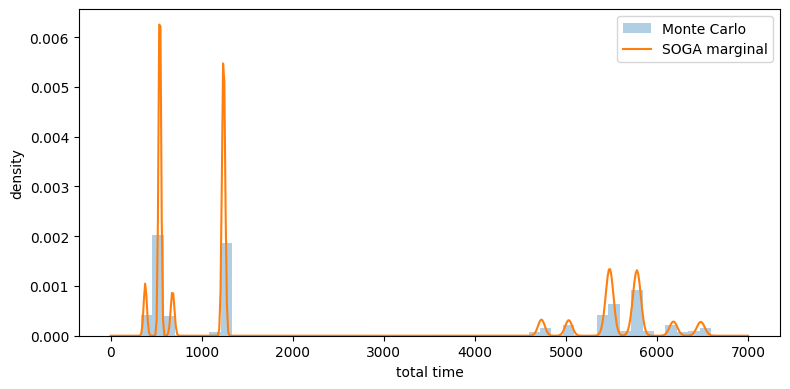

In [9]:
# Compare the purchasing model against Monte Carlo simulation.

def simulate_purchasing_once(params):
    tacts = torch.zeros(21, dtype=torch.float64)
    endacts = torch.zeros(21, dtype=torch.float64)
    t = 0.0

    mus = [float(params[f"mu{i}"]) ** 2 for i in range(21)]
    probs = [float(params[f"p{i}"]) ** 2 for i in range(6)]

    for i, mean in enumerate(mus):
        tacts[i] = sample_positive_normal(mean)

    def u01():
        return torch.rand(()).item()

    # Start -> Create Purchase Requisition
    endacts[0] = t + tacts[0]
    t = endacts[0].item()

    # After Create Purchase Requisition
    if u01() < probs[0]:
        endacts[1] = t + tacts[1]
        t = endacts[1].item()

        if u01() < probs[1]:
            endacts[2] = t + tacts[2]
            t = endacts[2].item()
    else:
        endacts[3] = t + tacts[3]
        t = endacts[3].item()

        endacts[4] = t + tacts[4]
        t = endacts[4].item()

        if u01() < probs[2]:
            endacts[5] = t + tacts[5]
            t = endacts[5].item()

        if u01() < probs[3]:
            endacts[6] = t + tacts[6]
            t = endacts[6].item()

            endacts[7] = t + tacts[7]
            t = endacts[7].item()

            endacts[8] = t + tacts[8]
            t = endacts[8].item()

            endacts[9] = t + tacts[9]
            t = endacts[9].item()

            endacts[10] = t + tacts[10]
            t = endacts[10].item()

            endacts[11] = t + tacts[11]
            t = endacts[11].item()

            endacts[12] = t + tacts[12]
            t = endacts[12].item()

            endacts[13] = t + tacts[13]
            t = endacts[13].item()

            endacts[14] = t + tacts[14]
            t = endacts[14].item()

            if u01() < probs[4]:
                endacts[15] = t + tacts[15]
                t = endacts[15].item()

                endacts[16] = t + tacts[16]
                t = endacts[16].item()

                endacts[17] = t + tacts[17]
                t = endacts[17].item()

            if u01() < probs[5]:
                endacts[18] = t + tacts[18]
                t = endacts[18].item()

            endacts[19] = t + tacts[19]
            t = endacts[19].item()

            endacts[20] = t + tacts[20]
            t = endacts[20].item()

    return endacts, t

purchasing_total_time_samples = torch.zeros(nsamples, dtype=torch.float64)
for i in range(nsamples):
    _, total_time_i = simulate_purchasing_once(params)
    purchasing_total_time_samples[i] = total_time_i

print("mean total time:", purchasing_total_time_samples.mean().item())

xs, pdf = hp.evaluate_marginal(output_dist, 't', 0, 7000, 500)
plt.figure(figsize=(8, 4))
plt.hist(purchasing_total_time_samples.numpy(), bins=50, density=True, alpha=0.35, label='Monte Carlo')
plt.plot(xs.numpy(), pdf.numpy(), label='SOGA marginal')
plt.xlabel('total time')
plt.ylabel('density')
plt.legend()
plt.tight_layout()
plt.show()
